# Atmospheric and Surface Basic State Changes (P1 vs P2)

This notebook generates a publication-quality 3 × 3 global map figure showing differences in the basic state between **P1 (1981–2006)** and **P2 (2007–2025)**:
- **Top row:** Sea surface temperature (SST, shaded in °C) with continents masked.
- **Middle row:** Surface pressure ($P_s$, shaded in hPa) overlaid with horizontal wind vectors ($u, v$ in $\mathrm{m\ s^{-1}}$) at 850 hPa ($\sigma = 0.83$).
- **Bottom row:** Specific humidity ($q$, shaded in $\mathrm{g\ kg^{-1}}$) at 850 hPa ($\sigma = 0.83$).

### Dataset & Methodology
- **Input NetCDF:** `/Users/rizzie/LinearBaroclinicModel/make_basic_state/output/basic_state_ncep_r2_era5sst_djf_all_periods.nc`
- **Atmospheric basic state:** NCEP/DOE Reanalysis 2 (DJF climatologies)
- **SST basic state:** ERA5 SST (DJF climatologies)
- **Vertical level:** Selected terrain-following sigma level $\sigma = 0.82977$ (level index 4), corresponding to $\sim$841 hPa assuming nominal surface pressure of 1013.25 hPa (or $\sim$830 hPa at 1000 hPa), which is the closest available sigma level to 850 hPa.
- **Climatological Periods:**
  - P1: 1981–2006 (period index 1)
  - P2: 2007–2025 (period index 2)
- **Units:** SST in °C, surface pressure in hPa, specific humidity in $\mathrm{g\ kg^{-1}}$, horizontal wind in $\mathrm{m\ s^{-1}}$.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.util as cutil
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Matplotlib font and aesthetic configuration matching publication reference
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Helvetica Neue', 'Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 13

In [2]:
# 1. Load dataset and inspect structure
nc_path = '/Users/rizzie/LinearBaroclinicModel/make_basic_state/output/basic_state_ncep_r2_era5sst_djf_all_periods.nc'
ds = xr.open_dataset(nc_path)

print("=== DATASET STRUCTURE ===")
print("Dimensions:", dict(ds.dims))
print("Coordinates:", list(ds.coords.keys()))
print("Variables:", list(ds.data_vars.keys()))
print("\nClimatological Periods in dataset:")
for i, name in enumerate(ds.period_name.values):
    p_str = name.decode() if isinstance(name, bytes) else str(name)
    print(f"  Index {i}: {p_str} ({ds.period_start_year.values[i]}–{ds.period_end_year.values[i]})")

=== DATASET STRUCTURE ===
Dimensions: {'period': 3, 'sigma': 20, 'lat': 32, 'lon': 64}
Coordinates: ['period', 'period_name', 'sigma', 'lat', 'lon']
Variables: ['period_start_year', 'period_end_year', 'u', 'v', 't', 'q', 'p', 'sst']

Climatological Periods in dataset:
  Index 0: 1981-2025 (1981–2025)
  Index 1: 1981-2006 (1981–2006)
  Index 2: 2007-2025 (2007–2025)


In [3]:
# 2. Vertical level selection and metadata verification
# Identify sigma level closest to 850 hPa assuming nominal Ps ~ 1000-1013.25 hPa
target_p = 850.0  # hPa
nominal_ps = 1013.25  # hPa
target_sigma = target_p / nominal_ps
closest_idx = int(np.argmin(np.abs(ds.sigma.values - target_sigma)))
sig_val = float(ds.sigma.values[closest_idx])

print(f"Target pressure: {target_p} hPa")
print(f"Selected sigma level: index {closest_idx} (sigma = {sig_val:.5f}, ~{sig_val * nominal_ps:.1f} hPa at Ps=1013.25 hPa)")

# Period indices: P1 (1981-2006) = 1, P2 (2007-2025) = 2
idx_p1 = 1
idx_p2 = 2

# 3. Extract variables and apply unit conversions
# Sea Surface Temperature: K -> °C
sst_p1 = (ds['sst'].isel(period=idx_p1) - 273.15).values
sst_p2 = (ds['sst'].isel(period=idx_p2) - 273.15).values
sst_diff = sst_p2 - sst_p1

# Surface Pressure: hPa
ps_p1 = ds['p'].isel(period=idx_p1).values
ps_p2 = ds['p'].isel(period=idx_p2).values
ps_diff = ps_p2 - ps_p1

# Specific humidity: kg kg-1 -> g kg-1
q_p1 = (ds['q'].isel(period=idx_p1, sigma=closest_idx) * 1000.0).values
q_p2 = (ds['q'].isel(period=idx_p2, sigma=closest_idx) * 1000.0).values
q_diff = q_p2 - q_p1

# Horizontal wind components: m s-1
u_p1 = ds['u'].isel(period=idx_p1, sigma=closest_idx).values
u_p2 = ds['u'].isel(period=idx_p2, sigma=closest_idx).values
u_diff = u_p2 - u_p1

v_p1 = ds['v'].isel(period=idx_p1, sigma=closest_idx).values
v_p2 = ds['v'].isel(period=idx_p2, sigma=closest_idx).values
v_diff = v_p2 - v_p1

lons = ds.lon.values
lats = ds.lat.values

# 4. Print robustness verification checks
print("\n=== ROBUSTNESS VERIFICATION ===")
print("Selected variables and units:")
print("  - Sea Surface Temperature (sst): converted from K to °C")
print("  - Surface Pressure (p): hPa")
print("  - Specific Humidity (q): converted from kg kg-1 to g kg-1")
print("  - Zonal Wind (u): m s-1")
print("  - Meridional Wind (v): m s-1")
print(f"Vertical level for u, v, q: sigma = {sig_val:.5f} (index {closest_idx})")
print(f"Periods: P1 = {ds.period_name.values[idx_p1].decode()} (idx {idx_p1}), P2 = {ds.period_name.values[idx_p2].decode()} (idx {idx_p2})")
print("\nMin/Max values after conversion:")
print(f"  SST_P1   : min = {sst_p1.min():.2f} °C, max = {sst_p1.max():.2f} °C")
print(f"  SST_P2   : min = {sst_p2.min():.2f} °C, max = {sst_p2.max():.2f} °C")
print(f"  SST_diff : min = {sst_diff.min():.2f} °C, max = {sst_diff.max():.2f} °C")
print(f"  Ps_P1    : min = {ps_p1.min():.2f} hPa, max = {ps_p1.max():.2f} hPa")
print(f"  Ps_P2    : min = {ps_p2.min():.2f} hPa, max = {ps_p2.max():.2f} hPa")
print(f"  Ps_diff  : min = {ps_diff.min():.2f} hPa, max = {ps_diff.max():.2f} hPa")
print(f"  q_P1     : min = {q_p1.min():.2f} g kg-1, max = {q_p1.max():.2f} g kg-1")
print(f"  q_P2     : min = {q_p2.min():.2f} g kg-1, max = {q_p2.max():.2f} g kg-1")
print(f"  q_diff   : min = {q_diff.min():.2f} g kg-1, max = {q_diff.max():.2f} g kg-1")
print(f"  u_P1     : min = {u_p1.min():.2f} m s-1, max = {u_p1.max():.2f} m s-1")
print(f"  u_P2     : min = {u_p2.min():.2f} m s-1, max = {u_p2.max():.2f} m s-1")
print(f"  u_diff   : min = {u_diff.min():.2f} m s-1, max = {u_diff.max():.2f} m s-1")
print(f"  v_P1     : min = {v_p1.min():.2f} m s-1, max = {v_p1.max():.2f} m s-1")
print(f"  v_P2     : min = {v_p2.min():.2f} m s-1, max = {v_p2.max():.2f} m s-1")
print(f"  v_diff   : min = {v_diff.min():.2f} m s-1, max = {v_diff.max():.2f} m s-1")

Target pressure: 850.0 hPa
Selected sigma level: index 4 (sigma = 0.82977, ~840.8 hPa at Ps=1013.25 hPa)

=== ROBUSTNESS VERIFICATION ===
Selected variables and units:
  - Sea Surface Temperature (sst): converted from K to °C
  - Surface Pressure (p): hPa
  - Specific Humidity (q): converted from kg kg-1 to g kg-1
  - Zonal Wind (u): m s-1
  - Meridional Wind (v): m s-1
Vertical level for u, v, q: sigma = 0.82977 (index 4)
Periods: P1 = 1981-2006 (idx 1), P2 = 2007-2025 (idx 2)

Min/Max values after conversion:
  SST_P1   : min = -44.10 °C, max = 37.02 °C
  SST_P2   : min = -42.83 °C, max = 37.72 °C
  SST_diff : min = -1.07 °C, max = 8.82 °C
  Ps_P1    : min = 616.17 hPa, max = 1026.37 hPa
  Ps_P2    : min = 614.65 hPa, max = 1026.73 hPa
  Ps_diff  : min = -5.86 hPa, max = 3.49 hPa
  q_P1     : min = 0.17 g kg-1, max = 11.74 g kg-1
  q_P2     : min = 0.18 g kg-1, max = 12.32 g kg-1
  q_diff   : min = -0.83 g kg-1, max = 1.40 g kg-1
  u_P1     : min = -11.31 m s-1, max = 16.12 m s-1
  u

Saved publication figure: basic_state_sst_q_ps-wind_850hPa_P1_P2.png


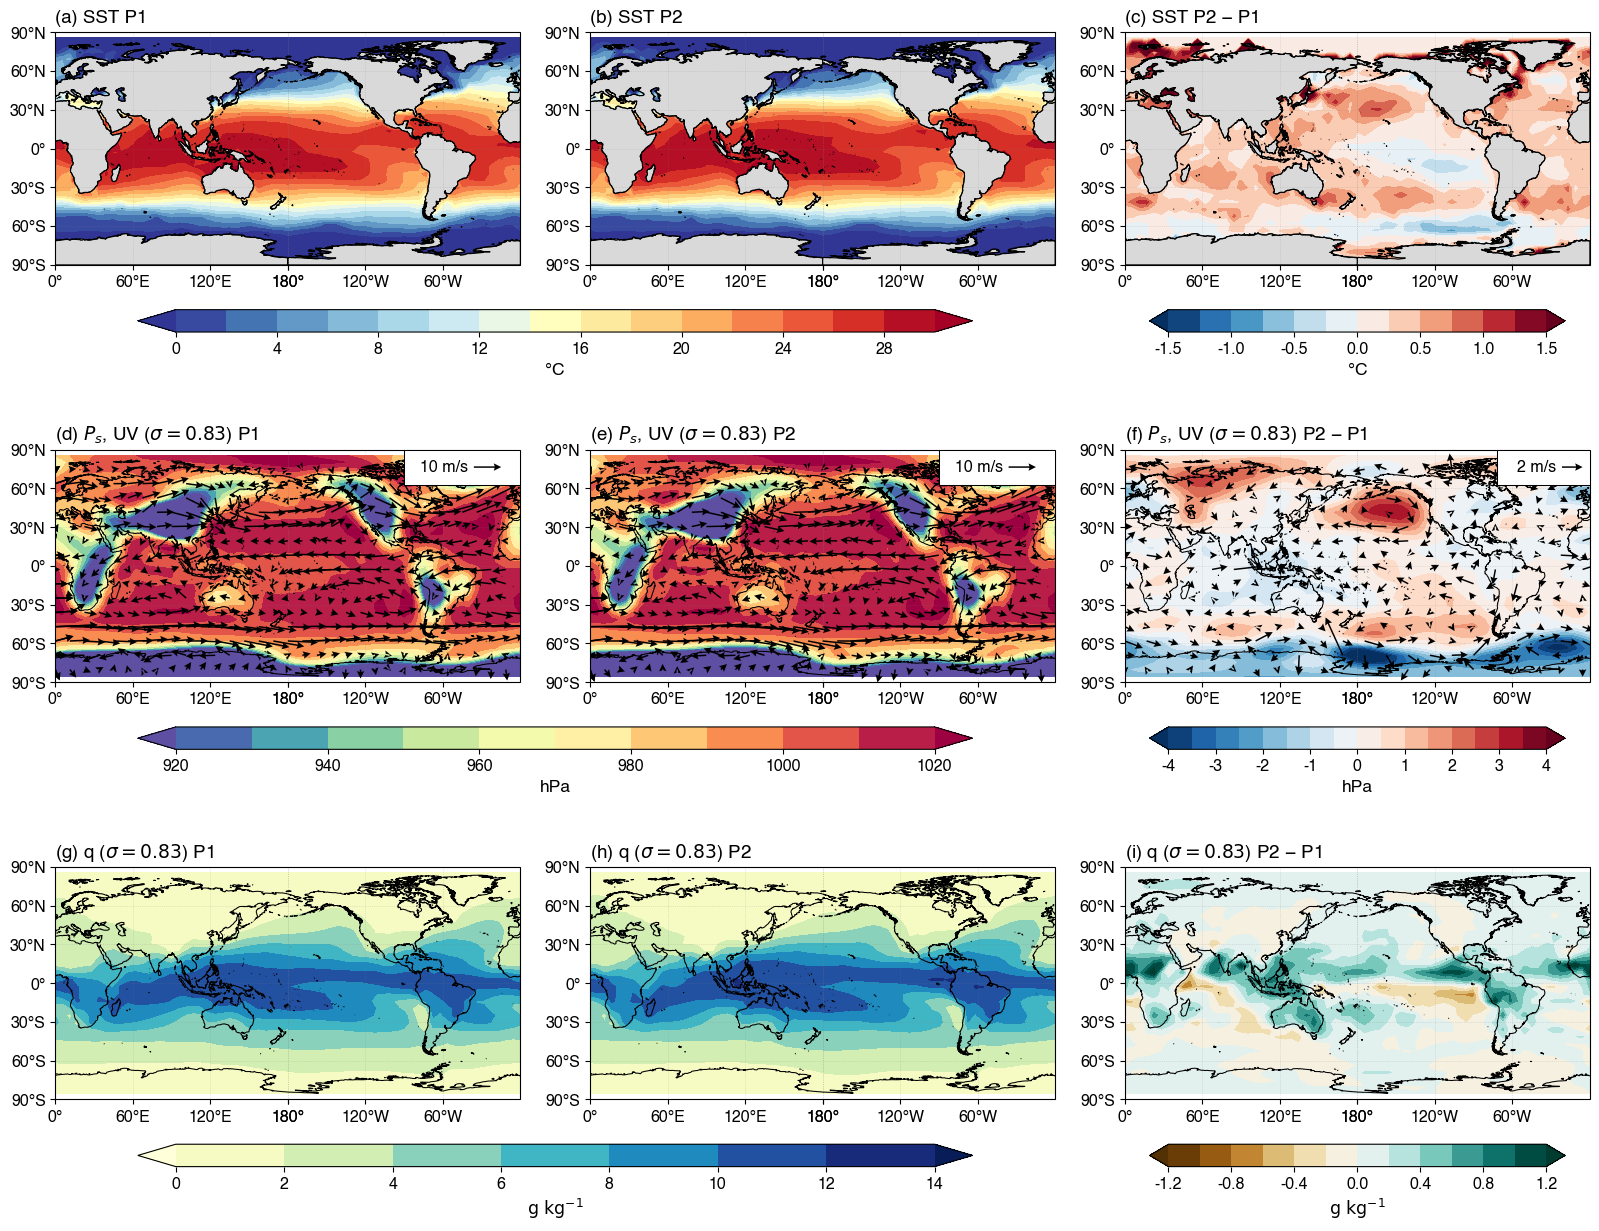

In [17]:
# 5. Add cyclic point to prevent seam at 0°/360° longitude
c_sst_p1, c_lon = cutil.add_cyclic_point(sst_p1, coord=lons)
c_sst_p2, _ = cutil.add_cyclic_point(sst_p2, coord=lons)
c_sst_diff, _ = cutil.add_cyclic_point(sst_diff, coord=lons)

c_ps_p1, _ = cutil.add_cyclic_point(ps_p1, coord=lons)
c_ps_p2, _ = cutil.add_cyclic_point(ps_p2, coord=lons)
c_ps_diff, _ = cutil.add_cyclic_point(ps_diff, coord=lons)

c_q_p1, _ = cutil.add_cyclic_point(q_p1, coord=lons)
c_q_p2, _ = cutil.add_cyclic_point(q_p2, coord=lons)
c_q_diff, _ = cutil.add_cyclic_point(q_diff, coord=lons)

c_u_p1, _ = cutil.add_cyclic_point(u_p1, coord=lons)
c_v_p1, _ = cutil.add_cyclic_point(v_p1, coord=lons)

c_u_p2, _ = cutil.add_cyclic_point(u_p2, coord=lons)
c_v_p2, _ = cutil.add_cyclic_point(v_p2, coord=lons)

c_u_diff, _ = cutil.add_cyclic_point(u_diff, coord=lons)
c_v_diff, _ = cutil.add_cyclic_point(v_diff, coord=lons)

# Subsampling grid for quiver vectors
lon_2d, lat_2d = np.meshgrid(c_lon, lats)

# Quiver styling matching Fig5 (minshaft=0, fixed head geometry, clean in-panel key box)
arrow_width = 0.0032
head_scale = 0.0020 / arrow_width

# Vector strides: exclude polar edge rows (lat index 0 and -1 at ±85.8°) to avoid border crowding
# For climatological winds (d, e): stride 2 in lat, 2 in lon
# For difference winds (f): reduced density by ~33% (stride 2 in lat, 3 in lon) for clearer circulation
stride_ab = (slice(1, -1, 2), slice(None, None, 2))
stride_c  = (slice(1, -1, 2), slice(None, None, 3))

# -----------------------------------------------------------------------------
# Layout configuration parameters:
# - GRID_HSPACE: controls vertical spacing between subplot rows (hspace)
# - GRID_WSPACE: controls horizontal spacing between subplot columns (wspace)
# - GRID_LEFT, GRID_RIGHT, GRID_BOTTOM, GRID_TOP: figure margins
# -----------------------------------------------------------------------------
FIGURE_WIDTH = 16.5
FIGURE_HEIGHT = 14
GRID_LEFT, GRID_RIGHT = 0.05, 0.98
GRID_BOTTOM, GRID_TOP = 0.08, 0.96
GRID_WSPACE = 0.15
GRID_HSPACE = 0.05       # <-- hspace configuration (adjust vertical space between rows)
COLORBAR_HEIGHT = 0.016
COLORBAR_PAD = 0.048

# 6. Set up 3 × 3 publication-quality figure with GridSpec
fig = plt.figure(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
gs = fig.add_gridspec(3, 3, left=GRID_LEFT, right=GRID_RIGHT, bottom=GRID_BOTTOM, top=GRID_TOP,
                      wspace=GRID_WSPACE, hspace=GRID_HSPACE)

proj = ccrs.PlateCarree(central_longitude=180)
lon_formatter = LongitudeFormatter(cardinal_labels={'east': 'E', 'west': 'W'})
lat_formatter = LatitudeFormatter(cardinal_labels={'north': 'N', 'south': 'S'})

def style_subplot(ax, title):
    ax.coastlines(resolution='50m', color='black', linewidth=0.75, zorder=3)
    ax.gridlines(xlocs=np.arange(-180, 181, 60), ylocs=np.arange(-90, 91, 30),
                 crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.5,
                 color='gray', alpha=0.35, linestyle=':')
    ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    ax.tick_params(labelsize=11.5, direction='out')
    ax.set_title(title, fontsize=13.5, pad=7, loc='left', fontname='Helvetica', fontweight='normal')

def add_cbar_axes(ax_left, ax_right, y_offset=COLORBAR_PAD, height=COLORBAR_HEIGHT, shrink_pad=0.0):
    pos_l = ax_left.get_position()
    pos_r = ax_right.get_position()
    left = pos_l.x0 + shrink_pad
    right = pos_r.x1 - shrink_pad
    y = pos_l.y0 - y_offset
    return fig.add_axes([left, y, right - left, height])

# Contour levels and colormaps
# Sea Surface Temperature (a, b): 0 to 30 °C, step 2 °C
levels_sst = np.arange(0, 31, 2)
norm_sst = mcolors.Normalize(vmin=0, vmax=30)
cmap_sst = plt.cm.RdYlBu_r

# Sea Surface Temperature difference (c): ±1.5 °C, step 0.25 °C
levels_sst_diff = np.arange(-1.5, 1.51, 0.25)
norm_sst_diff = mcolors.Normalize(vmin=-1.5, vmax=1.5)
cmap_sst_diff = plt.cm.RdBu_r

# Surface Pressure (d, e): 920 to 1020 hPa, step 10 hPa
levels_ps = np.arange(920, 1026, 10)
norm_ps = mcolors.Normalize(vmin=920, vmax=1020)
cmap_ps = plt.cm.Spectral_r

# Surface Pressure difference (f): ±4.0 hPa, step 0.5 hPa
levels_ps_diff = np.arange(-4.0, 4.01, 0.5)
norm_ps_diff = mcolors.Normalize(vmin=-4.0, vmax=4.0)
cmap_ps_diff = plt.cm.RdBu_r

# Specific humidity (g, h): 0 to 14 g kg-1, step 2 g kg-1
levels_q = np.arange(0, 14.1, 2)
norm_q = mcolors.Normalize(vmin=0, vmax=14)
cmap_q = plt.cm.YlGnBu

# Specific humidity difference (i): ±1.2 g kg-1, step 0.2 g kg-1
levels_q_diff = np.arange(-1.2, 1.21, 0.2)
norm_q_diff = mcolors.Normalize(vmin=-1.2, vmax=1.2)
cmap_q_diff = plt.cm.BrBG

# --- ROW 1: Sea Surface Temperature ---
# (a) P1
ax_a = fig.add_subplot(gs[0, 0], projection=proj)
im_a = ax_a.contourf(c_lon, lats, c_sst_p1, levels=levels_sst, cmap=cmap_sst, norm=norm_sst,
                     transform=ccrs.PlateCarree(), extend='both')
ax_a.add_feature(cfeature.LAND, facecolor='#d9d9d9', edgecolor='black', linewidth=0.75, zorder=2)
style_subplot(ax_a, r"(a) SST P1")

# (b) P2
ax_b = fig.add_subplot(gs[0, 1], projection=proj)
im_b = ax_b.contourf(c_lon, lats, c_sst_p2, levels=levels_sst, cmap=cmap_sst, norm=norm_sst,
                     transform=ccrs.PlateCarree(), extend='both')
ax_b.add_feature(cfeature.LAND, facecolor='#d9d9d9', edgecolor='black', linewidth=0.75, zorder=2)
style_subplot(ax_b, r"(b) SST P2")

# (c) P2 - P1
ax_c = fig.add_subplot(gs[0, 2], projection=proj)
im_c = ax_c.contourf(c_lon, lats, c_sst_diff, levels=levels_sst_diff, cmap=cmap_sst_diff, norm=norm_sst_diff,
                     transform=ccrs.PlateCarree(), extend='both')
ax_c.add_feature(cfeature.LAND, facecolor='#d9d9d9', edgecolor='black', linewidth=0.75, zorder=2)
style_subplot(ax_c, r"(c) SST P2 − P1")

# Colorbars for Row 1
cax_sst_ab = add_cbar_axes(ax_a, ax_b, shrink_pad=0.05)
cb_sst_ab = fig.colorbar(im_a, cax=cax_sst_ab, orientation='horizontal', ticks=levels_sst[::2])
cb_sst_ab.set_label(label="°C", size=12.5, fontname='Helvetica')
cb_sst_ab.ax.tick_params(labelsize=11.5)

cax_sst_c = add_cbar_axes(ax_c, ax_c, shrink_pad=0.015)
cb_sst_c = fig.colorbar(im_c, cax=cax_sst_c, orientation='horizontal', ticks=np.arange(-1.5, 1.51, 0.5))
cb_sst_c.set_label(label="°C", size=12.5, fontname='Helvetica')
cb_sst_c.ax.tick_params(labelsize=11.5)

# --- ROW 2: Surface Pressure & Wind Vectors ---
# (d) P1
ax_d = fig.add_subplot(gs[1, 0], projection=proj)
im_d = ax_d.contourf(c_lon, lats, c_ps_p1, levels=levels_ps, cmap=cmap_ps, norm=norm_ps,
                     transform=ccrs.PlateCarree(), extend='both')
q_d = ax_d.quiver(lon_2d[stride_ab], lat_2d[stride_ab],
                  c_u_p1[stride_ab], c_v_p1[stride_ab],
                  transform=ccrs.PlateCarree(), color='black', scale=170,
                  width=arrow_width,
                  headwidth=8 * head_scale, headlength=8 * head_scale, headaxislength=7 * head_scale,
                  minshaft=0, minlength=0, zorder=4)

# Solid white, no transparency, docked to top/right (x=0.60, w=0.40, y=0.85, h=0.15)
key_box_d = mpatches.Rectangle((0.75, 0.85), 0.25, 0.15, transform=ax_d.transAxes,
                               facecolor='white', edgecolor='black', linewidth=0.75, zorder=5)
ax_d.add_patch(key_box_d)
qk_d = ax_d.quiverkey(q_d, X=0.9, Y=0.925, U=10.0, label='10 m/s',
                      labelpos='W', coordinates='axes',
                      fontproperties={'family': 'Helvetica', 'size': 11.5}, labelsep=0.06)
qk_d.set_zorder(6)
qk_d.text.set_zorder(7)
style_subplot(ax_d, r"(d) $P_s$, UV ($\sigma = 0.83$) P1")

# (e) P2
ax_e = fig.add_subplot(gs[1, 1], projection=proj)
im_e = ax_e.contourf(c_lon, lats, c_ps_p2, levels=levels_ps, cmap=cmap_ps, norm=norm_ps,
                     transform=ccrs.PlateCarree(), extend='both')
q_e = ax_e.quiver(lon_2d[stride_ab], lat_2d[stride_ab],
                  c_u_p2[stride_ab], c_v_p2[stride_ab],
                  transform=ccrs.PlateCarree(), color='black', scale=170,
                  width=arrow_width,
                  headwidth=8 * head_scale, headlength=8 * head_scale, headaxislength=7 * head_scale,
                  minshaft=0, minlength=0, zorder=4)

key_box_e = mpatches.Rectangle((0.75, 0.85), 0.25, 0.15, transform=ax_e.transAxes,
                               facecolor='white', edgecolor='black', linewidth=0.75, zorder=5)
ax_e.add_patch(key_box_e)
qk_e = ax_e.quiverkey(q_e, X=0.90, Y=0.925, U=10.0, label='10 m/s',
                      labelpos='W', coordinates='axes',
                      fontproperties={'family': 'Helvetica', 'size': 11.5}, labelsep=0.06)
qk_e.set_zorder(6)
qk_e.text.set_zorder(7)
style_subplot(ax_e, r"(e) $P_s$, UV ($\sigma = 0.83$) P2")

# (f) P2 - P1
ax_f = fig.add_subplot(gs[1, 2], projection=proj)
im_f = ax_f.contourf(c_lon, lats, c_ps_diff, levels=levels_ps_diff, cmap=cmap_ps_diff, norm=norm_ps_diff,
                     transform=ccrs.PlateCarree(), extend='both')
q_f = ax_f.quiver(lon_2d[stride_c], lat_2d[stride_c],
                  c_u_diff[stride_c], c_v_diff[stride_c],
                  transform=ccrs.PlateCarree(), color='black', scale=45,
                  width=arrow_width,
                  headwidth=8 * head_scale, headlength=8 * head_scale, headaxislength=7 * head_scale,
                  minshaft=0, minlength=0, zorder=4)

key_box_f = mpatches.Rectangle((0.8, 0.85), 0.2, 0.15, transform=ax_f.transAxes,
                               facecolor='white', edgecolor='black', linewidth=0.75, zorder=5)
ax_f.add_patch(key_box_f)
qk_f = ax_f.quiverkey(q_f, X=0.94, Y=0.925, U=2.0, label='2 m/s',
                      labelpos='W', coordinates='axes',
                      fontproperties={'family': 'Helvetica', 'size': 11.5}, labelsep=0.06)
qk_f.set_zorder(6)
qk_f.text.set_zorder(7)
style_subplot(ax_f, r"(f) $P_s$, UV ($\sigma = 0.83$) P2 − P1")

# Colorbars for Row 2
cax_ps_ab = add_cbar_axes(ax_d, ax_e, shrink_pad=0.05)
cb_ps_ab = fig.colorbar(im_d, cax=cax_ps_ab, orientation='horizontal', ticks=levels_ps[::2])
cb_ps_ab.set_label(label="hPa", size=12.5, fontname='Helvetica')
cb_ps_ab.ax.tick_params(labelsize=11.5)

cax_ps_c = add_cbar_axes(ax_f, ax_f, shrink_pad=0.015)
cb_ps_c = fig.colorbar(im_f, cax=cax_ps_c, orientation='horizontal', ticks=np.arange(-4, 4.1, 1))
cb_ps_c.set_label(label="hPa", size=12.5, fontname='Helvetica')
cb_ps_c.ax.tick_params(labelsize=11.5)

# --- ROW 3: Specific Humidity ---
# (g) P1
ax_g = fig.add_subplot(gs[2, 0], projection=proj)
im_g = ax_g.contourf(c_lon, lats, c_q_p1, levels=levels_q, cmap=cmap_q, norm=norm_q,
                     transform=ccrs.PlateCarree(), extend='both')
style_subplot(ax_g, r"(g) q ($\sigma = 0.83$) P1")

# (h) P2
ax_h = fig.add_subplot(gs[2, 1], projection=proj)
im_h = ax_h.contourf(c_lon, lats, c_q_p2, levels=levels_q, cmap=cmap_q, norm=norm_q,
                     transform=ccrs.PlateCarree(), extend='both')
style_subplot(ax_h, r"(h) q ($\sigma = 0.83$) P2")

# (i) P2 - P1
ax_i = fig.add_subplot(gs[2, 2], projection=proj)
im_i = ax_i.contourf(c_lon, lats, c_q_diff, levels=levels_q_diff, cmap=cmap_q_diff, norm=norm_q_diff,
                     transform=ccrs.PlateCarree(), extend='both')
style_subplot(ax_i, r"(i) q ($\sigma = 0.83$) P2 − P1")

# Colorbars for Row 3
cax_q_de = add_cbar_axes(ax_g, ax_h, shrink_pad=0.05)
cb_q_de = fig.colorbar(im_g, cax=cax_q_de, orientation='horizontal', ticks=levels_q)
cb_q_de.set_label(label=r"$\mathrm{g\ kg^{-1}}$", size=12.5, fontname='Helvetica')
cb_q_de.ax.tick_params(labelsize=11.5)

cax_q_f = add_cbar_axes(ax_i, ax_i, shrink_pad=0.015)
cb_q_f = fig.colorbar(im_i, cax=cax_q_f, orientation='horizontal', ticks=np.arange(-1.2, 1.21, 0.4))
cb_q_f.set_label(label=r"$\mathrm{g\ kg^{-1}}$", size=12.5, fontname='Helvetica')
cb_q_f.ax.tick_params(labelsize=11.5)

# Save publication-quality figures (PNG only, 300 dpi)
png_out = 'basic_state_sst_q_ps-wind_850hPa_P1_P2.png'
plt.savefig(png_out, dpi=300)
print(f"Saved publication figure: {png_out}")
plt.show()
